# Instagram Engagement Predictor 🚀

This notebook trains multiple machine learning models to predict Instagram engagement metrics based on user profile data and post content. The system analyzes:

- **Engagement Rate**: Overall post engagement
- **Comment Count**: Expected number of comments
- **Comment Sentiment**: Predicted sentiment of comments (Positive/Neutral/Negative)
- **Sentiment-Weighted Engagement**: Comment count weighted by sentiment score

## Features Used:
- User profile metrics (followers, followees, posts)
- Post content (caption, hashtags, media type)
- Advanced text analysis (BERT embeddings, sentiment/emotion analysis)
- Category information

## Models Implemented:
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- Neural Networks (TensorFlow)

---

In [ ]:
# Install required libraries
!pip install transformers torch lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow

print("✅ All libraries installed successfully!")

^C
✅ All libraries installed successfully!


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/149.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/149.9 MB 2.8 MB/s eta 0:00:54
   ---------------------------------------- 1.3/149.9 MB 3.7 MB/s eta 0:00:40
    --------------------------------------- 2.1/149.9 MB 3.9 MB/s eta 0:00:38
    --------------------------------------- 3.1/149.9 MB 4.1 MB/s eta 0:00:36
   - -------------------------------------- 4.5/149.9 MB 4.5 MB/s eta 0:00:33
   - -------------------------------------- 5.2/149.9 MB 4.5 MB/s eta 0:00:33
   - -------------------------------------- 5.2/149.9 MB 4.5 MB/s eta 0:00:33
   - -------------------------------------- 5.8/149.9 MB 3.6 MB/s eta 0:00:41
   - ---

## 📚 Import Libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import torch
from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported successfully!")

c:\Users\Chinthana\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully!


## 📁 Upload and Load Dataset

Upload your Instagram dataset CSV file using the file upload widget below.

In [4]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from transformers import pipeline
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Initialize sentiment analysis pipeline with truncation
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,  # Truncate sequences to max_length
    max_length=512,   # Maximum token length
    device=0 if torch.cuda.is_available() else -1  # Use GPU if available
)

# Define get_sentiment_features function
def get_sentiment_features(caption):
    """
    Extract sentiment features from a caption using a pre-trained sentiment analysis model.
    Args:
        caption (str): The Instagram caption to analyze.
    Returns:
        dict: Dictionary containing sentiment score, label, and confidence.
    """
    if not isinstance(caption, str) or len(caption.strip()) == 0:
        return {
            'sentiment_score': 0.0,
            'sentiment_label': 'neutral',
            'sentiment_confidence': 0.0
        }

    try:
        # Run sentiment analysis with truncation
        result = sentiment_analyzer(caption)[0]
        sentiment_score = result['score'] if result['label'] == 'POSITIVE' else -result['score']
        sentiment_label = result['label'].lower()
        sentiment_confidence = result['score']
        return {
            'sentiment_score': sentiment_score,
            'sentiment_label': sentiment_label,
            'sentiment_confidence': sentiment_confidence
        }
    except Exception as e:
        print(f"Error processing caption: {e}")
        return {
            'sentiment_score': 0.0,
            'sentiment_label': 'neutral',
            'sentiment_confidence': 0.0
        }

# Load dataset from local path
csv_path = r"C:\Users\Chinthana\Desktop\Krishantha\New\balanced_posts_with_sentiment_emotion_analysis.csv"
print(f"Loading dataset from: {csv_path}")

try:
    data = pd.read_csv(csv_path)
    print(f"\n✅ File loaded successfully!")
    print(f"Dataset shape: {data.shape}")
except FileNotFoundError:
    print(f"\n❌ Error: File not found at {csv_path}")
    print("Please check if the file exists and the path is correct.")
    exit()
except Exception as e:
    print(f"\n❌ Error loading file: {e}")
    exit()

# Handle missing values
data['caption'] = data['caption'].fillna('')
data['hashtags'] = data['hashtags'].fillna('')
data['media_type'] = data['media_type'].fillna('image')
data['Category'] = data['Category'].fillna('unknown')

# Encode categorical variables
le_media_type = LabelEncoder()
data['media_type_encoded'] = le_media_type.fit_transform(data['media_type'])
le_category = LabelEncoder()
data['category_encoded'] = le_category.fit_transform(data['Category'])

# Check for long captions
print("Checking for captions exceeding 512 tokens...")
data['token_count'] = data['caption'].apply(lambda x: len(str(x).split()))
long_captions = data[data['token_count'] > 500]
if not long_captions.empty:
    print(f"Found {len(long_captions)} captions with >500 tokens:")
    print(long_captions[['caption', 'token_count']].head())

# Batch processing with Dataset for efficiency
def batch_sentiment_features(captions, batch_size=100):
    dataset = Dataset.from_dict({'caption': captions})
    sentiment_features_list = []

    def process_batch(batch):
        try:
            results = sentiment_analyzer(batch['caption'], truncation=True, max_length=512)
            return [
                {
                    'sentiment_score': r['score'] if r['label'] == 'POSITIVE' else -r['score'],
                    'sentiment_label': r['label'].lower(),
                    'sentiment_confidence': r['score']
                } for r in results
            ]
        except Exception as e:
            print(f"Error in batch: {e}")
            return [{'sentiment_score': 0.0, 'sentiment_label': 'neutral', 'sentiment_confidence': 0.0}] * len(batch['caption'])

    print("Applying sentiment and emotion analysis...")
    for i in range(0, len(captions), batch_size):
        batch = dataset[i:i + batch_size]
        batch_features = process_batch(batch)
        sentiment_features_list.extend(batch_features)
        print(f"Processed {i + len(batch['caption'])}/{len(captions)} captions")

    return pd.DataFrame(sentiment_features_list)

# Apply sentiment analysis
sentiment_features_df = batch_sentiment_features(data['caption'].tolist())
data = pd.concat([data, sentiment_features_df], axis=1)

# Display the first few rows
print("\nUpdated dataset with sentiment features:")
print(data.head())

Device set to use cpu


Loading dataset from: C:\Users\Chinthana\Desktop\Krishantha\New\balanced_posts_with_sentiment_emotion_analysis.csv

✅ File loaded successfully!
Dataset shape: (11022, 54)
Checking for captions exceeding 512 tokens...
Applying sentiment and emotion analysis...
Processed 100/11022 captions
Processed 200/11022 captions
Processed 300/11022 captions
Processed 400/11022 captions
Processed 500/11022 captions
Processed 600/11022 captions
Processed 700/11022 captions
Processed 800/11022 captions
Processed 900/11022 captions
Processed 1000/11022 captions
Processed 1100/11022 captions
Processed 1200/11022 captions
Processed 1300/11022 captions
Processed 1400/11022 captions
Processed 1500/11022 captions
Processed 1600/11022 captions
Processed 1700/11022 captions
Processed 1800/11022 captions
Processed 1900/11022 captions
Processed 2000/11022 captions
Processed 2100/11022 captions
Processed 2200/11022 captions
Processed 2300/11022 captions
Processed 2400/11022 captions
Processed 2500/11022 captions

## 🔄 Data Preprocessing

Clean and prepare the data for model training.

In [5]:
# Data Preprocessing
print("🔄 Starting data preprocessing...")

# Handle missing values
data = data.fillna({
    'caption': '',
    'hashtags': '',
    'location': '',
    'comment_owner_username': '',
    'mentions': ''
})

# Display missing values before and after
print("\n📊 Missing values per column:")
missing_counts = data.isnull().sum()
print(missing_counts[missing_counts > 0])

# Display basic statistics
print("\n📈 Dataset Statistics:")
print(f"Total posts: {len(data)}")
print(f"Unique users: {data['username'].nunique()}")
print(f"Media types: {data['media_type'].value_counts().to_dict()}")
print(f"Categories: {data['Category'].value_counts().to_dict()}")

print("\n✅ Data preprocessing completed!")

🔄 Starting data preprocessing...

📊 Missing values per column:
owner_id                         4
timestamp                        4
likes                            4
comments_count                   4
location_id                   7511
username                         6
shortcode                        6
is_private                       6
is_verified                      6
#Followers                       6
#Followees                       6
#Posts                           6
comment_likes                    6
comment_timestamp                6
caption_length                   6
num_hashtags                     6
has_mention                      6
has_url                          6
follower_adjusted_likes          6
follower_adjusted_comments       6
engagement_rate                  6
hashtags_agg                  4259
engagement_frequency             6
influence_score                  6
content_interaction              6
comment_engagement_ratio         6
comment_length             

## 🧠 Sentiment and Emotion Analysis

Initialize pre-trained models for text analysis.

In [7]:
# Initialize BERT tokenizer and model
print("🤖 Initializing BERT model...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

# Check for GPU availability
device = 0 if torch.cuda.is_available() else -1
if device == 0:
    bert_model = bert_model.to('cuda')
    print("✅ Using GPU for BERT model")
else:
    print("ℹ️ Using CPU for BERT model")

# Initialize sentiment and emotion pipelines
print("\n🎭 Initializing sentiment and emotion analysis pipelines...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

emotion_pipeline = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    device=device
)

print("✅ All NLP models initialized successfully!")

🤖 Initializing BERT model...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Error while downloading from https://huggingface.co/bert-base-uncased/resolve/main/model.safetensors: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


ℹ️ Using CPU for BERT model

🎭 Initializing sentiment and emotion analysis pipelines...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this

✅ All NLP models initialized successfully!


In [9]:
# Sentiment and Emotion Analysis Functions
def analyze_text(text):
    """Analyze sentiment and emotion of given text"""
    if not text or pd.isna(text) or len(text.strip()) == 0:
        return {
            'sentiment_label': 'neutral',
            'sentiment_score': 0.0,
            'emotion_label': 'neutral',
            'emotion_score': 0.0
        }

    try:
        sentiment = sentiment_pipeline(text, truncation=True, max_length=512)[0]
        emotion = emotion_pipeline(text, truncation=True, max_length=512)[0]

        # Map sentiment labels
        sentiment_label_mapping = {
            'LABEL_0': 'negative',
            'LABEL_1': 'neutral',
            'LABEL_2': 'positive'
        }
        sentiment_label = sentiment_label_mapping.get(sentiment['label'], 'neutral')

        return {
            'sentiment_label': sentiment_label,
            'sentiment_score': sentiment['score'],
            'emotion_label': emotion['label'],
            'emotion_score': emotion['score']
        }
    except Exception as e:
        print(f"Error analyzing text: {e}")
        return {
            'sentiment_label': 'neutral',
            'sentiment_score': 0.0,
            'emotion_label': 'neutral',
            'emotion_score': 0.0
        }

def get_sentiment_features(caption):
    """Extract comprehensive sentiment features from caption"""
    analysis = analyze_text(caption)

    # Convert sentiment to numeric value
    sentiment_to_numeric = {'negative': -1, 'neutral': 0, 'positive': 1}
    sentiment_value = sentiment_to_numeric.get(analysis['sentiment_label'], 0)
    effective_sentiment = sentiment_value * analysis['sentiment_score']

    return {
        'caption_effective_sentiment': effective_sentiment,
        'caption_ml_sentiment': analysis['sentiment_label'],
        'caption_sentiment_score': analysis['sentiment_score'],
        'caption_emotion': analysis['emotion_label'],
        'caption_emotion_score': analysis['emotion_score']
    }

# Function to get BERT embeddings
def get_bert_embeddings(texts, batch_size=16):
    """Generate BERT embeddings for a list of texts"""
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_embeddings = []

        for text in batch_texts:
            if not text or pd.isna(text):
                batch_embeddings.append(np.zeros(768))
                continue

            try:
                inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
                if device == 0:
                    inputs = {k: v.to('cuda') for k, v in inputs.items()}

                with torch.no_grad():
                    outputs = bert_model(**inputs)

                embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
                batch_embeddings.append(embedding)

            except Exception as e:
                print(f"Error generating embedding: {e}")
                batch_embeddings.append(np.zeros(768))

        embeddings.extend(batch_embeddings)

        if i % (batch_size * 10) == 0:
            print(f"Processed {i + len(batch_texts)}/{len(texts)} texts")

    return np.array(embeddings)

print("✅ Text analysis functions defined!")

✅ Text analysis functions defined!


## ⚙️ Feature Engineering

Generate advanced features including BERT embeddings, TF-IDF features, and sentiment analysis.

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from transformers import pipeline
from datasets import Dataset
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming get_bert_embeddings is defined elsewhere
def get_bert_embeddings(texts, batch_size=160):
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased').to('cuda' if torch.cuda.is_available() else 'cpu')
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
        print(f"Processed {i + len(batch_texts)}/{len(texts)} texts")
    return np.vstack(embeddings)

print("⚙️ Starting feature engineering...")

# Encode categorical variables
print("\n🏷️ Encoding categorical variables...")
le_media_type = LabelEncoder()
data['media_type_encoded'] = le_media_type.fit_transform(data['media_type'])

le_category = LabelEncoder()
data['category_encoded'] = le_category.fit_transform(data['Category'])

# Combine caption and hashtags for comprehensive text analysis
print("\n📝 Combining text features...")
data['text_combined'] = data['caption'].fillna('') + ' ' + data['hashtags'].fillna('')

# Generate BERT embeddings
print("\n🧠 Generating BERT embeddings (this may take a while)...")
bert_embeddings = get_bert_embeddings(data['text_combined'].tolist())
bert_df = pd.DataFrame(bert_embeddings, columns=[f'bert_{i}' for i in range(bert_embeddings.shape[1])])
data = pd.concat([data.reset_index(drop=True), bert_df.reset_index(drop=True)], axis=1)
print(f"✅ Generated {bert_embeddings.shape[1]} BERT features")

# Extract TF-IDF features
print("\n📊 Extracting TF-IDF features...")
tfidf = TfidfVectorizer(max_features=500, stop_words='english', min_df=2, max_df=0.9)
tfidf_matrix = tfidf.fit_transform(data['text_combined'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()])
data = pd.concat([data.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)
print(f"✅ Generated {len(tfidf.get_feature_names_out())} TF-IDF features")

# Initialize sentiment analysis pipeline with truncation
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1
)

# Initialize emotion analysis pipeline
emotion_analyzer = pipeline(
    "text-classification",
    model="bhadresh-savani/distilbert-base-uncased-emotion",
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1
)

# Define get_sentiment_features function
def get_sentiment_features(caption):
    if not isinstance(caption, str) or len(caption.strip()) == 0:
        return {
            'caption_effective_sentiment': 0.0,
            'caption_ml_sentiment': 'neutral',
            'caption_sentiment_score': 0.0,
            'caption_emotion': 'neutral',
            'caption_emotion_score': 0.0
        }
    try:
        sentiment_result = sentiment_analyzer(caption)[0]
        sentiment_score = sentiment_result['score'] if sentiment_result['label'] == 'POSITIVE' else -sentiment_result['score']
        sentiment_label = sentiment_result['label'].lower()
        emotion_result = emotion_analyzer(caption)[0]
        emotion_label = emotion_result['label']
        emotion_score = emotion_result['score']
        return {
            'caption_effective_sentiment': sentiment_score,
            'caption_ml_sentiment': sentiment_label,
            'caption_sentiment_score': sentiment_result['score'],
            'caption_emotion': emotion_label,
            'caption_emotion_score': emotion_score
        }
    except Exception as e:
        print(f"Error processing caption: {e}")
        return {
            'caption_effective_sentiment': 0.0,
            'caption_ml_sentiment': 'neutral',
            'caption_sentiment_score': 0.0,
            'caption_emotion': 'neutral',
            'caption_emotion_score': 0.0
        }

# Batch process sentiment and emotion analysis
def batch_sentiment_features(captions, batch_size=100):
    dataset = Dataset.from_dict({'caption': captions})
    sentiment_features_list = []

    def process_batch(batch):
        try:
            sentiment_results = sentiment_analyzer(batch['caption'], truncation=True, max_length=512)
            emotion_results = emotion_analyzer(batch['caption'], truncation=True, max_length=512)
            batch_features = []
            for s_result, e_result in zip(sentiment_results, emotion_results):
                s_score = s_result['score'] if s_result['label'] == 'POSITIVE' else -s_result['score']
                batch_features.append({
                    'caption_effective_sentiment': s_score,
                    'caption_ml_sentiment': s_result['label'].lower(),
                    'caption_sentiment_score': s_result['score'],
                    'caption_emotion': e_result['label'],
                    'caption_emotion_score': e_result['score']
                })
            return batch_features
        except Exception as e:
            print(f"Error in batch: {e}")
            return [{
                'caption_effective_sentiment': 0.0,
                'caption_ml_sentiment': 'neutral',
                'caption_sentiment_score': 0.0,
                'caption_emotion': 'neutral',
                'caption_emotion_score': 0.0
            }] * len(batch['caption'])

    print("Applying sentiment and emotion analysis...")
    for i in range(0, len(captions), batch_size):
        batch = dataset[i:i + batch_size]
        batch_features = process_batch(batch)
        sentiment_features_list.extend(batch_features)
        print(f"Processed {i + len(batch['caption'])}/{len(captions)} captions")

    return pd.DataFrame(sentiment_features_list)

# Apply sentiment and emotion analysis
print("\n🎭 Applying sentiment and emotion analysis...")
sentiment_features_df = batch_sentiment_features(data['caption'].tolist())

# Debug: Check sentiment DataFrame
print("\n🔍 Sentiment DataFrame head:\n", sentiment_features_df.head())
print("\n🔍 Caption sentiment values:\n", sentiment_features_df['caption_ml_sentiment'].values)
print("\n🔍 Caption emotion values:\n", sentiment_features_df['caption_emotion'].values)

# Ensure sentiment_df columns are strings where needed
sentiment_features_df['caption_ml_sentiment'] = sentiment_features_df['caption_ml_sentiment'].astype(str)
sentiment_features_df['caption_emotion'] = sentiment_features_df['caption_emotion'].astype(str)

# Drop existing sentiment/emotion columns to avoid duplication
columns_to_drop = ['caption_effective_sentiment', 'caption_ml_sentiment', 'caption_sentiment_score',
                   'caption_emotion', 'caption_emotion_score']
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns], errors='ignore')

# Concatenate sentiment_df with data
data = pd.concat([data.reset_index(drop=True), sentiment_features_df.reset_index(drop=True)], axis=1)

# Debug: Check data columns after concatenation
print("\n🔍 Data columns after concatenation:\n", data.columns.tolist())
print("\n🔍 caption_ml_sentiment values in data:\n", data['caption_ml_sentiment'].values)

# Encode newly created categorical features
print("\n🏷️ Encoding sentiment and emotion labels...")
le_sentiment = LabelEncoder()
data['caption_ml_sentiment'] = data['caption_ml_sentiment'].astype(str)
data['caption_ml_sentiment_encoded'] = le_sentiment.fit_transform(data['caption_ml_sentiment'])
print(f"✅ Encoded sentiments: {list(le_sentiment.classes_)}")

le_emotion = LabelEncoder()
data['caption_emotion'] = data['caption_emotion'].astype(str)
data['caption_emotion_encoded'] = le_emotion.fit_transform(data['caption_emotion'])
print(f"✅ Encoded emotions: {list(le_emotion.classes_)}")

# Handle comments_sentiment_score
print("\n🔍 Inspecting comments_sentiment_score...")
print(data['comments_sentiment_score'].head())
print("Data type of comments_sentiment_score:", data['comments_sentiment_score'].dtype)

# If comments_sentiment_score is non-numeric, map to numeric values
if not np.issubdtype(data['comments_sentiment_score'].dtype, np.number):
    print("Converting comments_sentiment_score to numeric...")
    sentiment_mapping = {
        'positive': 1.0,
        'neutral': 0.0,
        'negative': -1.0,
        'nan': 0.0
    }
    data['comments_sentiment_score_numeric'] = data['comments_sentiment_score'].astype(str).map(sentiment_mapping).fillna(0.0)
else:
    data['comments_sentiment_score_numeric'] = data['comments_sentiment_score']

# Inspect and convert comments_count to numeric
print("\n🔍 Inspecting comments_count...")
print(data['comments_count'].head())
print("Data type of comments_count:", data['comments_count'].dtype)
print("Unique values in comments_count:", data['comments_count'].unique()[:10])

print("\n🔍 Converting comments_count to numeric...")
data['comments_count'] = pd.to_numeric(data['comments_count'], errors='coerce').fillna(0).astype(int)
print("Data type of comments_count after conversion:", data['comments_count'].dtype)

# Calculate sentiment-weighted engagement
print("\n📈 Calculating sentiment-weighted engagement...")
data['sentiment_weighted_engagement'] = data['comments_count'] * data['comments_sentiment_score_numeric']

print(f"\n✅ Feature engineering completed!")
print(f"Total features: {data.shape[1]}")

⚙️ Starting feature engineering...

🏷️ Encoding categorical variables...

📝 Combining text features...

🧠 Generating BERT embeddings (this may take a while)...
Processed 160/11022 texts
Processed 320/11022 texts
Processed 480/11022 texts
Processed 640/11022 texts
Processed 800/11022 texts
Processed 960/11022 texts
Processed 1120/11022 texts
Processed 1280/11022 texts
Processed 1440/11022 texts
Processed 1600/11022 texts
Processed 1760/11022 texts
Processed 1920/11022 texts
Processed 2080/11022 texts
Processed 2240/11022 texts
Processed 2400/11022 texts
Processed 2560/11022 texts
Processed 2720/11022 texts
Processed 2880/11022 texts
Processed 3040/11022 texts
Processed 3200/11022 texts
Processed 3360/11022 texts
Processed 3520/11022 texts
Processed 3680/11022 texts
Processed 3840/11022 texts
Processed 4000/11022 texts
Processed 4160/11022 texts
Processed 4320/11022 texts
Processed 4480/11022 texts
Processed 4640/11022 texts
Processed 4800/11022 texts
Processed 4960/11022 texts
Processed

Device set to use cpu
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu



🎭 Applying sentiment and emotion analysis...
Applying sentiment and emotion analysis...
Processed 100/11022 captions
Processed 200/11022 captions
Processed 300/11022 captions
Processed 400/11022 captions
Processed 500/11022 captions
Processed 600/11022 captions
Processed 700/11022 captions
Processed 800/11022 captions
Processed 900/11022 captions
Processed 1000/11022 captions
Processed 1100/11022 captions
Processed 1200/11022 captions
Processed 1300/11022 captions
Processed 1400/11022 captions
Processed 1500/11022 captions
Processed 1600/11022 captions
Processed 1700/11022 captions
Processed 1800/11022 captions
Processed 1900/11022 captions
Processed 2000/11022 captions
Processed 2100/11022 captions
Processed 2200/11022 captions
Processed 2300/11022 captions
Processed 2400/11022 captions
Processed 2500/11022 captions
Processed 2600/11022 captions
Processed 2700/11022 captions
Processed 2800/11022 captions
Processed 2900/11022 captions
Processed 3000/11022 captions
Processed 3100/11022

## 🔄 Split Data into Train and Test Sets

Prepare features and targets for model training.

In [12]:
print("🔄 Preparing features and targets...")

# Select features for model training
base_features = [
    '#Followers', '#Followees', '#Posts', 'media_type_encoded', 'category_encoded',
    'caption_length', 'num_hashtags', 'has_emoji', 'has_mention', 'has_url',
    'caption_effective_sentiment', 'caption_sentiment_score', 'caption_emotion_score',
    'caption_ml_sentiment_encoded', 'caption_emotion_encoded'
]

# Add BERT features
bert_features = [f'bert_{i}' for i in range(bert_embeddings.shape[1])]

# Add TF-IDF features
tfidf_features = [f'tfidf_{word}' for word in tfidf.get_feature_names_out()]

# Combine all features
features = base_features + bert_features + tfidf_features

# Check which features exist in the dataset
available_features = [f for f in features if f in data.columns]
missing_features = [f for f in features if f not in data.columns]

if missing_features:
    print(f"⚠️ Missing features: {missing_features[:5]}{'...' if len(missing_features) > 5 else ''}")

print(f"✅ Using {len(available_features)} features for training")

# Prepare feature matrix
X = data[available_features].fillna(0)

# Prepare target variables
y_engagement = data['engagement_rate'].fillna(0)
y_comments = data['comments_count'].fillna(0)

# Handle comments_sentiment mapping
sentiment_mapping = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
y_sentiment = data['comments_sentiment'].map(sentiment_mapping).fillna(0)

y_weighted_engagement = data['sentiment_weighted_engagement'].fillna(0)

# Split data into training and testing sets
print("\n📊 Splitting data...")
X_train, X_test, y_engagement_train, y_engagement_test = train_test_split(
    X, y_engagement, test_size=0.2, random_state=42
)

_, _, y_comments_train, y_comments_test = train_test_split(
    X, y_comments, test_size=0.2, random_state=42
)

_, _, y_sentiment_train, y_sentiment_test = train_test_split(
    X, y_sentiment, test_size=0.2, random_state=42
)

_, _, y_weighted_engagement_train, y_weighted_engagement_test = train_test_split(
    X, y_weighted_engagement, test_size=0.2, random_state=42
)

print(f"✅ Data split completed!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")

🔄 Preparing features and targets...
✅ Using 1283 features for training

📊 Splitting data...
✅ Data split completed!
Training set: 8817 samples
Test set: 2205 samples
Features: 2551


## 📏 Scale Features

Standardize features for optimal model performance.

In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Debug: Check if X_train exists and is properly defined
print(f"\n🔍 X_train type: {type(X_train)}")
print(f"🔍 X_train shape: {X_train.shape}")

# Check for duplicate columns
duplicate_cols = X_train.columns[X_train.columns.duplicated()].tolist()
if duplicate_cols:
    print(f"⚠️ Found duplicate columns: {duplicate_cols[:10]}...")
    # Remove duplicate columns
    X_train = X_train.loc[:, ~X_train.columns.duplicated()]
    X_test = X_test.loc[:, ~X_test.columns.duplicated()]
    print(f"✅ Removed duplicates. New shape: {X_train.shape}")

print("\n🔍 Inspecting X_train data types:")
print(X_train.dtypes.head(10))

print("\n🔍 Non-numeric columns:")
non_numeric_cols = X_train.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns
print(f"Found {len(non_numeric_cols)} non-numeric columns")
if len(non_numeric_cols) > 0:
    print(list(non_numeric_cols)[:10])

# Convert boolean-like columns to numeric
print("\n🔄 Processing columns for type conversion...")
for col in X_train.columns:
    try:
        # Ensure we're working with a valid column and it's a Series
        if col in X_train.columns:
            # Get the column as a Series - fix the indexing issue
            col_series = X_train.loc[:, col]
            
            # Check if it's actually a Series (not DataFrame)
            if isinstance(col_series, pd.DataFrame):
                print(f"⚠️ Column {col} returned DataFrame instead of Series, taking first column")
                col_series = col_series.iloc[:, 0]
            
            # Check the dtype of the Series
            if col_series.dtype == 'object':
                # Handle string representations of booleans
                unique_vals = set(col_series.dropna().astype(str).unique())
                if unique_vals.issubset({'True', 'False', 'nan'}):
                    print(f"🔍 Converting {col} from string boolean to numeric...")
                    X_train.loc[:, col] = col_series.astype(str).map({'True': 1, 'False': 0, 'nan': 0}).fillna(0).astype(int)
                    X_test.loc[:, col] = X_test.loc[:, col].astype(str).map({'True': 1, 'False': 0, 'nan': 0}).fillna(0).astype(int)
            elif col_series.dtype == 'bool':
                print(f"🔍 Converting {col} from boolean to numeric...")
                X_train.loc[:, col] = col_series.astype(int)
                X_test.loc[:, col] = X_test.loc[:, col].astype(int)
                
    except Exception as e:
        print(f"⚠️ Error processing column {col}: {e}")
        continue

# Select only numeric columns for scaling
print("\n🔍 Selecting numeric columns...")
numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32', 'uint8']).columns
print(f"Found {len(numeric_cols)} numeric columns")

if len(numeric_cols) == 0:
    print("❌ No numeric columns found! This indicates a data preparation issue.")
    print("Available columns:", X_train.columns.tolist()[:10])
    print("Data types:", X_train.dtypes.head())
    raise ValueError("No numeric columns available for scaling")

X_train_numeric = X_train[numeric_cols].copy()
X_test_numeric = X_test[numeric_cols].copy()

# Handle any remaining NaN values
print("\n🔍 Handling NaN values...")
nan_counts_train = X_train_numeric.isnull().sum()
nan_counts_test = X_test_numeric.isnull().sum()

if nan_counts_train.sum() > 0:
    print(f"Found {nan_counts_train.sum()} NaN values in training data. Filling with 0...")
    X_train_numeric = X_train_numeric.fillna(0)

if nan_counts_test.sum() > 0:
    print(f"Found {nan_counts_test.sum()} NaN values in test data. Filling with 0...")
    X_test_numeric = X_test_numeric.fillna(0)

# Check for infinite values
print("\n🔍 Checking for infinite values...")
inf_train = np.isinf(X_train_numeric).sum().sum()
inf_test = np.isinf(X_test_numeric).sum().sum()

if inf_train > 0:
    print(f"Found {inf_train} infinite values in training data. Replacing with 0...")
    X_train_numeric = X_train_numeric.replace([np.inf, -np.inf], 0)

if inf_test > 0:
    print(f"Found {inf_test} infinite values in test data. Replacing with 0...")
    X_test_numeric = X_test_numeric.replace([np.inf, -np.inf], 0)

# Debug: Verify numeric columns
print("\n🔍 Final numeric columns for scaling:")
print(f"Shape: {X_train_numeric.shape}")
print(f"Sample columns: {X_train_numeric.columns.tolist()[:10]}...")

# Scale features using StandardScaler
print("\n📏 Scaling features...")
try:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_numeric)
    X_test_scaled = scaler.transform(X_test_numeric)
    
    print(f"✅ Features scaled successfully!")
    print(f"Training set shape: {X_train_scaled.shape}")
    print(f"Test set shape: {X_test_scaled.shape}")
    
except Exception as e:
    print(f"❌ Error during scaling: {e}")
    print("Data info:")
    print(f"X_train_numeric dtypes: {X_train_numeric.dtypes.value_counts()}")
    print(f"X_train_numeric shape: {X_train_numeric.shape}")
    print(f"Contains inf values: {np.isinf(X_train_numeric).any().any()}")
    print(f"Contains NaN values: {X_train_numeric.isnull().any().any()}")
    raise


🔍 X_train type: <class 'pandas.core.frame.DataFrame'>
🔍 X_train shape: (8817, 2551)
⚠️ Found duplicate columns: ['bert_0', 'bert_1', 'bert_2', 'bert_3', 'bert_4', 'bert_5', 'bert_6', 'bert_7', 'bert_8', 'bert_9']...
✅ Removed duplicates. New shape: (8817, 1283)

🔍 Inspecting X_train data types:
#Followers            float64
#Followees            float64
#Posts                float64
media_type_encoded      int64
category_encoded        int64
caption_length        float64
num_hashtags          float64
has_emoji              object
has_mention            object
has_url                object
dtype: object

🔍 Non-numeric columns:
Found 3 non-numeric columns
['has_emoji', 'has_mention', 'has_url']

🔄 Processing columns for type conversion...

🔍 Selecting numeric columns...
Found 1280 numeric columns

🔍 Handling NaN values...

🔍 Checking for infinite values...

🔍 Final numeric columns for scaling:
Shape: (8817, 1280)
Sample columns: ['#Followers', '#Followees', '#Posts', 'media_type_encoded

## 🤖 Define Models

Set up regression and classification models for training.

In [21]:
# Define Neural Network for regression
def build_nn_regressor(input_dim):
    """Build a neural network for regression tasks"""
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Define Neural Network for classification
def build_nn_classifier(input_dim, num_classes=3):
    """Build a neural network for classification tasks"""
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model evaluation functions
def evaluate_regression(y_true, y_pred, model_name):
    """Evaluate regression model performance"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

def evaluate_classification(y_true, y_pred, model_name):
    """Evaluate classification model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}

print("✅ Model definitions completed!")

✅ Model definitions completed!


## 📈 Train and Evaluate Regression Models

Train models to predict engagement rate, comment count, and sentiment-weighted engagement.

In [22]:
# Define regression models
models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

# Store results
all_results_reg = []

# 1. Engagement Rate Prediction

# 2. Comment Count Prediction
print("💬 Training models for Comment Count Prediction...")
for name, model in models_reg.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_scaled, y_comments_train)
        y_pred = model.predict(X_test_scaled)
        result = evaluate_regression(y_comments_test, y_pred, f"{name} (Comments)")
        all_results_reg.append(result)
        print(f"✅ {name} - R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.4f}")
    except Exception as e:
        print(f"❌ Error with {name}: {e}")

# Neural Network for Comment Count
print("Training Neural Network for Comment Count...")
try:
    nn_comments = build_nn_regressor(X_train_scaled.shape[1])
    nn_comments.fit(
        X_train_scaled, y_comments_train,
        epochs=50, batch_size=32, verbose=0,
        validation_split=0.2
    )
    y_pred_nn = nn_comments.predict(X_test_scaled).flatten()
    result = evaluate_regression(y_comments_test, y_pred_nn, "Neural Network (Comments)")
    all_results_reg.append(result)
    print(f"✅ Neural Network - R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.4f}")
except Exception as e:
    print(f"❌ Error with Neural Network: {e}")

print("\n" + "="*50)

# 3. Sentiment-Weighted Engagement Prediction
print("🎭 Training models for Sentiment-Weighted Engagement Prediction...")
for name, model in models_reg.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_scaled, y_weighted_engagement_train)
        y_pred = model.predict(X_test_scaled)
        result = evaluate_regression(y_weighted_engagement_test, y_pred, f"{name} (Weighted)")
        all_results_reg.append(result)
        print(f"✅ {name} - R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.4f}")
    except Exception as e:
        print(f"❌ Error with {name}: {e}")

# Neural Network for Sentiment-Weighted Engagement
print("Training Neural Network for Sentiment-Weighted Engagement...")
try:
    nn_weighted = build_nn_regressor(X_train_scaled.shape[1])
    nn_weighted.fit(
        X_train_scaled, y_weighted_engagement_train,
        epochs=50, batch_size=32, verbose=0,
        validation_split=0.2
    )
    y_pred_nn = nn_weighted.predict(X_test_scaled).flatten()
    result = evaluate_regression(y_weighted_engagement_test, y_pred_nn, "Neural Network (Weighted)")
    all_results_reg.append(result)
    print(f"✅ Neural Network - R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.4f}")
except Exception as e:
    print(f"❌ Error with Neural Network: {e}")

print("\n✅ Regression model training completed!")

💬 Training models for Comment Count Prediction...
Training Linear Regression...
✅ Linear Regression - R²: 0.3766, RMSE: 472.5366
Training Random Forest...
✅ Random Forest - R²: 0.4419, RMSE: 447.1210
Training Gradient Boosting...
✅ Gradient Boosting - R²: 0.4236, RMSE: 454.4030
Training XGBoost...
✅ XGBoost - R²: 0.2900, RMSE: 504.3012
Training LightGBM...
✅ LightGBM - R²: 0.5411, RMSE: 405.4346
Training Neural Network for Comment Count...
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
✅ Neural Network - R²: 0.1513, RMSE: 551.3850

🎭 Training models for Sentiment-Weighted Engagement Prediction...
Training Linear Regression...
✅ Linear Regression - R²: 0.3655, RMSE: 431.8324
Training Random Forest...
✅ Random Forest - R²: 0.4338, RMSE: 407.9262
Training Gradient Boosting...
✅ Gradient Boosting - R²: 0.3954, RMSE: 421.5412
Training XGBoost...
✅ XGBoost - R²: 0.2935, RMSE: 455.6899
Training LightGBM...
✅ LightGBM - R²: 0.5164, RMSE: 376.9990
Training Neural Network for Sentiment-Weighted Engage

## 🎯 Train and Evaluate Classification Models

Train models to predict comment sentiment.

In [23]:
# Define classification models
models_clf = {
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'XGBoost Classifier': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'LightGBM Classifier': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
}

# Define evaluation function
def evaluate_classification(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

# Define neural network model
def build_nn_classifier(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train and evaluate models
all_results_clf = []
print("🎭 Training models for Comment Sentiment Prediction...")

# Check sentiment distribution in dataset
print("🎭 Checking sentiment distribution in dataset...")
sentiment_column = None
if 'comments_sentiment' in data.columns:
    sentiment_column = 'comments_sentiment'
elif 'comments_effective_sentiment' in data.columns:
    sentiment_column = 'comments_effective_sentiment'
elif 'comments_ml_sentiment' in data.columns:
    sentiment_column = 'comments_ml_sentiment'
else:
    print("⚠️ No comments sentiment column found. Using 'caption' to compute sentiment labels.")

if sentiment_column:
    print(f"Sentiment column: {sentiment_column}")
    print(f"Class distribution:\n{pd.Series(data[sentiment_column]).value_counts()}")
    unique_classes = np.unique(data[sentiment_column].dropna())
    if len(unique_classes) < 2:
        print("⚠️ Only one sentiment class found. Attempting to recompute sentiment labels...")
        sentiment_column = None

# Recompute sentiment labels if necessary
if sentiment_column is None:
    if 'caption' in data.columns:
        def get_sentiment_features_for_classification(text):
            if not isinstance(text, str) or len(text.strip()) == 0:
                return 0  # Neutral for empty or invalid text
            result = sentiment_analyzer(text)[0]
            if result['score'] < 0.4:  # Low confidence -> neutral
                return 0
            return 1 if result['label'] == 'POSITIVE' else -1

        print("Computing sentiment labels for caption...")
        data['computed_sentiment'] = data['caption'].apply(get_sentiment_features_for_classification)
        sentiment_column = 'computed_sentiment'
        print(f"New class distribution:\n{pd.Series(data[sentiment_column]).value_counts()}")
        unique_classes = np.unique(data[sentiment_column])
        if len(unique_classes) < 2:
            print("❌ Still only one sentiment class. Skipping classification task.")
            # Optionally add fallback regression here if needed
            # y = data['sentiment_weighted_engagement'] if 'sentiment_weighted_engagement' in data.columns else data['likes']
            # safe_features = ['caption_sentiment_score', '#Followers', '#Followees', '#Posts', 'caption_length', 'num_hashtags']
            # available_features = [col for col in safe_features if col in data.columns]
            # ... rest of regression fallback
            pass # Skip classification if only one class
        else:
             print("\nPreparing data for classification...")

    else:
        print("❌ No 'caption' column found to compute sentiment labels. Skipping classification task.")
        # Optionally add fallback regression here if needed
        pass # Skip classification if no caption

if sentiment_column and len(unique_classes) >= 2:
    # Prepare data for classification
    y_sentiment = data[sentiment_column]
    safe_features = ['caption_sentiment_score', '#Followers', '#Followees', '#Posts', 'caption_length', 'num_hashtags']
    available_features = [col for col in safe_features if col in data.columns]
    X = data[available_features]
    X_train, X_test, y_sentiment_train, y_sentiment_test = train_test_split(X, y_sentiment, test_size=0.4, random_state=42, stratify=y_sentiment) # Added stratify
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Remap labels to [0, 1, ...]
    unique_classes_train = np.unique(y_sentiment_train)
    print(f"Unique classes in y_sentiment_train: {unique_classes_train}")

    label_encoder = LabelEncoder()
    y_sentiment_train_shifted = label_encoder.fit_transform(y_sentiment_train)
    y_sentiment_test_shifted = label_encoder.transform(y_sentiment_test)
    print(f"Remapped classes in y_sentiment_train: {np.unique(y_sentiment_train_shifted)}")
    print(f"Remapped classes mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}") # Debug print

    for name, model in models_clf.items():
        print(f"Training {name}...")
        try:
            model.fit(X_train_scaled, y_sentiment_train_shifted)
            y_pred_shifted = model.predict(X_test_scaled)
            y_pred = label_encoder.inverse_transform(y_pred_shifted)  # Convert back to original labels
            result = evaluate_classification(y_sentiment_test, y_pred, name)
            all_results_clf.append(result)
            print(f"✅ {name} - Accuracy: {result['Accuracy']:.4f}, F1: {result['F1']:.4f}")
            # Cross-validation
            try:
                cv_scores = cross_val_score(model, X_train_scaled, y_sentiment_train_shifted, cv=min(5, len(X_train)//2), scoring='accuracy') # Adjusted cv for small dataset
                print(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            except Exception as cv_e:
                 print(f"❌ Error during cross-validation for {name}: {cv_e}")

        except Exception as e:
            print(f"❌ Error with {name}: {e}")

    # Neural Network
    print("Training Neural Network for Sentiment Classification...")
    try:
        nn_sentiment = build_nn_classifier(X_train_scaled.shape[1], num_classes=len(label_encoder.classes_)) # Use number of classes from label_encoder
        nn_sentiment.fit(
            X_train_scaled, y_sentiment_train_shifted,
            epochs=50, batch_size=32, verbose=0,
            validation_split=0.2
        )
        y_pred_proba = nn_sentiment.predict(X_test_scaled)
        y_pred_shifted = np.argmax(y_pred_proba, axis=1)
        y_pred = label_encoder.inverse_transform(y_pred_shifted)
        result = evaluate_classification(y_sentiment_test, y_pred, "Neural Network Classifier")
        all_results_clf.append(result)
        print(f"✅ Neural Network - Accuracy: {result['Accuracy']:.4f}, F1: {result['F1']:.4f}")
    except Exception as e:
        print(f"❌ Error with Neural Network: {e}")

    print("\n✅ Classification model training completed!")
    print("\n📊 Classification Results Summary:")
    for result in all_results_clf:
        print(f"{result['Model']}: Accuracy = {result['Accuracy']:.4f}, F1 = {result['F1']:.4f}")
else:
    print("\n⚠️ Classification skipped due to insufficient sentiment classes.")

🎭 Training models for Comment Sentiment Prediction...
🎭 Checking sentiment distribution in dataset...
Sentiment column: comments_sentiment
Class distribution:
comments_sentiment
Positive    9972
Neutral      878
Negative     172
Name: count, dtype: int64
Unique classes in y_sentiment_train: ['Negative' 'Neutral' 'Positive']
Remapped classes in y_sentiment_train: [0 1 2]
Remapped classes mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Training Random Forest Classifier...
✅ Random Forest Classifier - Accuracy: 0.9004, F1: 0.8824
Cross-validation accuracy: 0.9049 ± 0.0033
Training Gradient Boosting Classifier...
❌ Error with Gradient Boosting Classifier: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible t

## 📊 Model Comparison

Compare all trained models based on their performance metrics.

In [26]:
# Create comparison dataframes
results_reg_df = pd.DataFrame(all_results_reg)
results_clf_df = pd.DataFrame(all_results_clf)

# Display regression results
print("📈 REGRESSION MODEL COMPARISON")
print("=" * 80)
if not results_reg_df.empty:
    print(results_reg_df.round(4))

    # Find best models for each task
    engagement_models = results_reg_df[results_reg_df['Model'].str.contains('Engagement')]
    comments_models = results_reg_df[results_reg_df['Model'].str.contains('Comments')]
    weighted_models = results_reg_df[results_reg_df['Model'].str.contains('Weighted')]

    print("\n🏆 BEST REGRESSION MODELS:")
    if not engagement_models.empty:
        best_engagement = engagement_models.loc[engagement_models['R²'].idxmax()]
        print(f"Engagement Rate: {best_engagement['Model']} (R² = {best_engagement['R²']:.4f})")

    if not comments_models.empty:
        best_comments = comments_models.loc[comments_models['R²'].idxmax()]
        print(f"Comment Count: {best_comments['Model']} (R² = {best_comments['R²']:.4f})")

    if not weighted_models.empty:
        best_weighted = weighted_models.loc[weighted_models['R²'].idxmax()]
        print(f"Weighted Engagement: {best_weighted['Model']} (R² = {best_weighted['R²']:.4f})")
else:
    print("No regression results available.")

print("\n" + "=" * 80)

# Display classification results
print("🎯 CLASSIFICATION MODEL COMPARISON")
print("=" * 80)
if not results_clf_df.empty:
    print(results_clf_df.round(4))

    # Find best classification model
    best_clf = results_clf_df.loc[results_clf_df['F1'].idxmax()]
    print(f"\n🏆 BEST CLASSIFICATION MODEL:")
    print(f"Comment Sentiment: {best_clf['Model']} (F1 = {best_clf['F1']:.4f})")
else:
    print("No classification results available.")

📈 REGRESSION MODEL COMPARISON
                           Model      RMSE       MAE      R²
0   Linear Regression (Comments)  472.5366  213.7031  0.3766
1       Random Forest (Comments)  447.1210   75.0005  0.4419
2   Gradient Boosting (Comments)  454.4030   77.2890  0.4236
3             XGBoost (Comments)  504.3012   76.4987  0.2900
4            LightGBM (Comments)  405.4346   76.5106  0.5411
5      Neural Network (Comments)  551.3850   88.0017  0.1513
6   Linear Regression (Weighted)  431.8324  186.4849  0.3655
7       Random Forest (Weighted)  407.9262   66.7448  0.4338
8   Gradient Boosting (Weighted)  421.5412   65.3585  0.3954
9             XGBoost (Weighted)  455.6899   67.6111  0.2935
10           LightGBM (Weighted)  376.9990   68.1716  0.5164
11     Neural Network (Weighted)  487.6681   74.3921  0.1909

🏆 BEST REGRESSION MODELS:
Comment Count: LightGBM (Comments) (R² = 0.5411)
Weighted Engagement: LightGBM (Weighted) (R² = 0.5164)

🎯 CLASSIFICATION MODEL COMPARISON
           

## 📊 Visualization

Visualize model performance across different metrics.

Device set to use cpu


Starting data preprocessing...
Extracting TF-IDF features from captions...
Generated 50 TF-IDF features
🎭 Checking sentiment distribution in dataset...
Sentiment column: comments_sentiment
Class distribution:
comments_sentiment
Positive    9972
Neutral      878
Negative     172
Name: count, dtype: int64
⚠️ Computing sentiment from captions...
New class distribution:
computed_sentiment
-1    7283
 1    2816
 0     923
Name: count, dtype: int64
⚠️ Using class_weight='balanced' instead of SMOTE for handling class imbalance.
Class weights: {np.int64(-1): np.float64(0.5044241037376049), np.int64(0): np.float64(3.9789410348977134), np.int64(1): np.float64(1.3051115058219853)}
Remapped classes in y_sentiment_train: [0 1 2]
Remapped classes mapping: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}
🎭 Training models for Comment Sentiment Prediction...
Training Random Forest Classifier...
✅ Random Forest Classifier - Accuracy: 0.7374, F1: 0.7374, Precision: 0.7375,

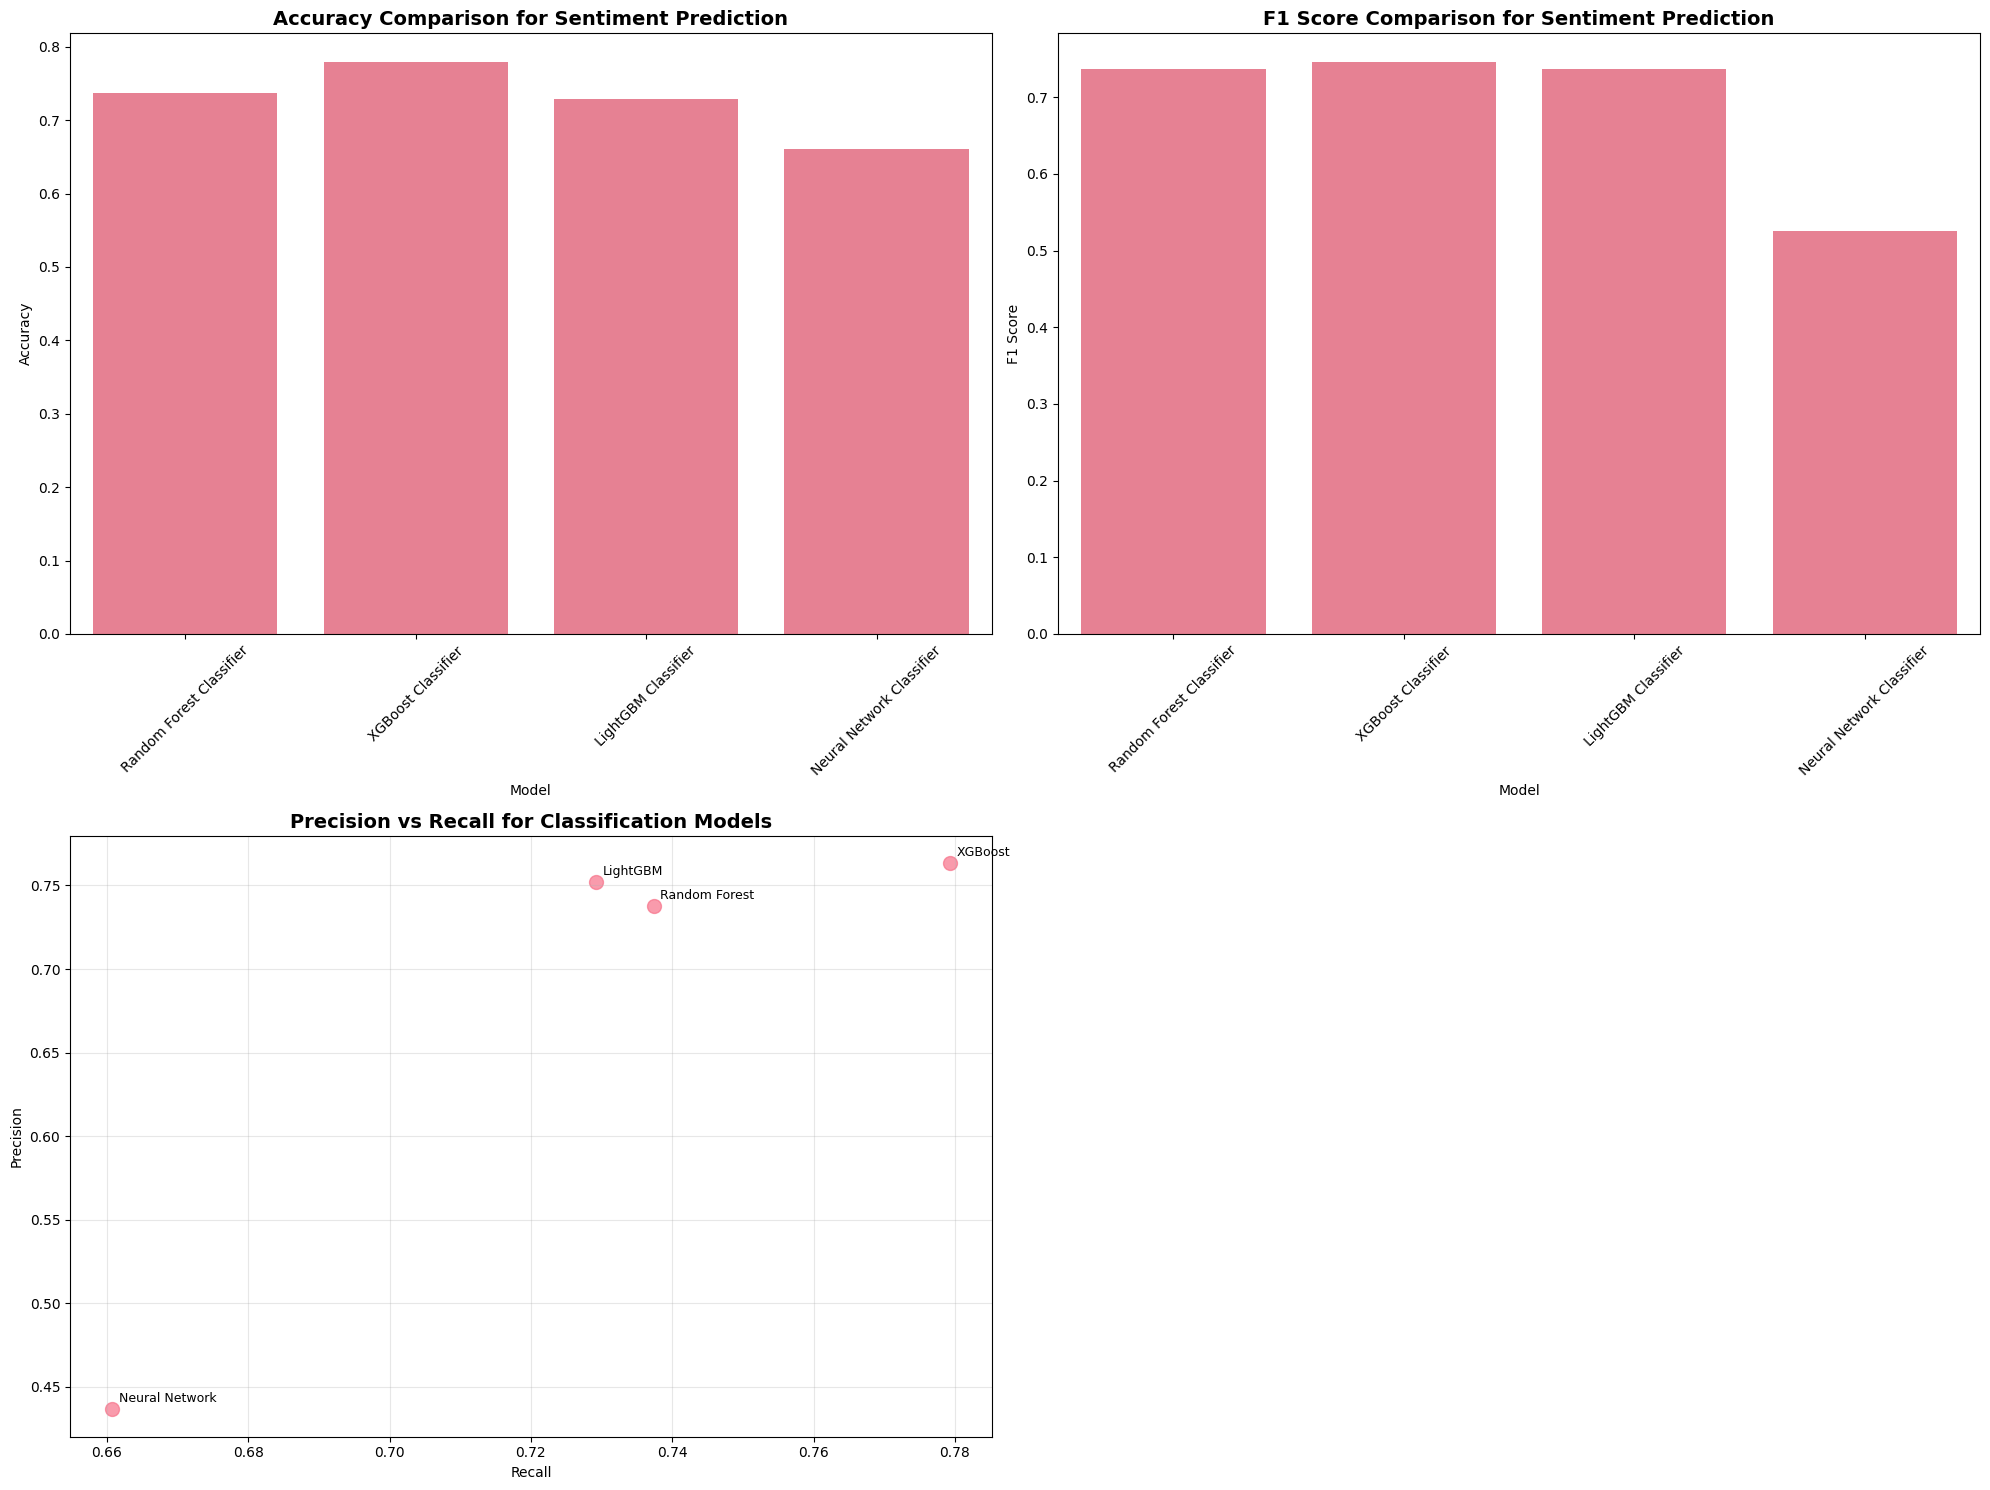

✅ Visualizations completed!


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from transformers import pipeline
# Remove SMOTE import - use alternative class balancing methods
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Initialize sentiment analysis pipeline with truncation
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Data Preprocessing
print("Starting data preprocessing...")
data['caption'] = data['caption'].fillna('')
data['hashtags'] = data['hashtags'].fillna('')
data['media_type'] = data['media_type'].fillna('image')
data['Category'] = data['Category'].fillna('unknown')

# Add TF-IDF features from captions - FIX: Properly handle column assignment
print("Extracting TF-IDF features from captions...")
tfidf = TfidfVectorizer(max_features=50, stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['caption']).toarray()

# Create column names based on actual number of features generated
actual_num_features = tfidf_matrix.shape[1]
print(f"Generated {actual_num_features} TF-IDF features")
tfidf_columns = [f'tfidf_{i}' for i in range(actual_num_features)]

# Create DataFrame with proper indexing
tfidf_df = pd.DataFrame(tfidf_matrix, columns=tfidf_columns, index=data.index)

# Concatenate instead of direct assignment to avoid dimension mismatch
data = pd.concat([data, tfidf_df], axis=1)

# Sentiment distribution
print("🎭 Checking sentiment distribution in dataset...")
sentiment_column = None
if 'comments_sentiment' in data.columns:
    print(f"Sentiment column: comments_sentiment")
    print(f"Class distribution:\n{pd.Series(data['comments_sentiment']).value_counts()}")
    unique_classes = np.unique(data['comments_sentiment'].dropna())
    if len(unique_classes) < 2:
        print("⚠️ Only one sentiment class found. Using comments_sentiment_score...")
        if 'comments_sentiment_score' in data.columns:
            print(f"Comments sentiment score distribution:\n{pd.Series(data['comments_sentiment_score']).describe()}")
            scores = data['comments_sentiment_score'].dropna()
            q1, q3 = scores.quantile([0.25, 0.75])
            def derive_sentiment_labels(score):
                if pd.isna(score):
                    return 0
                if score < q1:
                    return -1
                elif score > q3:
                    return 1
                else:
                    return 0
            data['derived_sentiment'] = data['comments_sentiment_score'].apply(derive_sentiment_labels)
            sentiment_column = 'derived_sentiment'
            print(f"Derived class distribution:\n{pd.Series(data[sentiment_column]).value_counts()}")
            unique_classes = np.unique(data[sentiment_column].dropna())

if sentiment_column is None or len(unique_classes) < 2:
    print("⚠️ Computing sentiment from captions...")
    def get_sentiment_features_for_classification(text):
        if not isinstance(text, str) or len(text.strip()) == 0:
            return 0
        try:
            result = sentiment_analyzer(text, truncation=True, max_length=512)[0]
            if result['score'] < 0.7:
                return 0
            return 1 if result['label'] == 'POSITIVE' else -1
        except Exception as e:
            print(f"Error analyzing text: {e}")
            return 0
    data['computed_sentiment'] = data['caption'].apply(get_sentiment_features_for_classification)
    sentiment_column = 'computed_sentiment'
    print(f"New class distribution:\n{pd.Series(data[sentiment_column]).value_counts()}")
    unique_classes = np.unique(data[sentiment_column])
    if len(unique_classes) < 2:
        print("❌ Still only one sentiment class. Switching to regression task.")
        y = data['sentiment_weighted_engagement'] if 'sentiment_weighted_engagement' in data.columns else data['likes']
        safe_features = ['caption_sentiment_score', '#Followers', '#Followees', '#Posts', 'caption_length', 'num_hashtags'] + tfidf_columns
        available_features = [col for col in safe_features if col in data.columns]
        X = data[available_features]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(n_estimators=50, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        print("✅ Regression Results:")
        print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
        print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
        print(f"R²: {r2_score(y_test, y_pred):.4f}")
        # Continue with visualizations instead of exiting
        results_clf_df = pd.DataFrame()
    else:
        # Prepare data for classification
        y_sentiment = data[sentiment_column]
        safe_features = ['caption_sentiment_score', '#Followers', '#Followees', '#Posts', 'caption_length', 'num_hashtags'] + tfidf_columns
        available_features = [col for col in safe_features if col in data.columns]
        X = data[available_features]
        X_train, X_test, y_sentiment_train, y_sentiment_test = train_test_split(X, y_sentiment, test_size=0.4, random_state=42, stratify=y_sentiment)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Alternative to SMOTE: Use class weights for handling class imbalance
        print("⚠️ Using class_weight='balanced' instead of SMOTE for handling class imbalance.")
        
        # Calculate class weights
        classes = np.unique(y_sentiment_train)
        class_weights = compute_class_weight('balanced', classes=classes, y=y_sentiment_train)
        class_weight_dict = dict(zip(classes, class_weights))
        print(f"Class weights: {class_weight_dict}")
        
        y_sentiment_train_shifted = y_sentiment_train
        y_sentiment_test_shifted = y_sentiment_test

        # Remap labels
        label_encoder = LabelEncoder()
        y_sentiment_train_shifted = label_encoder.fit_transform(y_sentiment_train_shifted)
        y_sentiment_test_shifted = label_encoder.transform(y_sentiment_test_shifted)
        print(f"Remapped classes in y_sentiment_train: {np.unique(y_sentiment_train_shifted)}")
        print(f"Remapped classes mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

        # Define simplified classification models with class balancing
        models_clf = {
            'Random Forest Classifier': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1, class_weight='balanced'),
            'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42),
            'XGBoost Classifier': XGBClassifier(n_estimators=50, max_depth=3, random_state=42, eval_metric='logloss', n_jobs=-1),
            'LightGBM Classifier': LGBMClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')
        }

        # Define evaluation function
        def evaluate_classification(y_true, y_pred, model_name):
            return {
                'Model': model_name,
                'Accuracy': accuracy_score(y_true, y_pred),
                'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
                'F1': f1_score(y_true, y_pred, average='weighted')
            }

        # Define simplified neural network
        def build_nn_classifier(input_dim, num_classes):
            model = Sequential([
                Dense(32, activation='relu', input_shape=(input_dim,)),
                Dense(16, activation='relu'),
                Dense(num_classes, activation='softmax')
            ])
            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return model

        # Train and evaluate models
        all_results_clf = []
        print("🎭 Training models for Comment Sentiment Prediction...")
        for name, model in models_clf.items():
            print(f"Training {name}...")
            try:
                model.fit(X_train_scaled, y_sentiment_train_shifted)
                y_pred_shifted = model.predict(X_test_scaled)
                y_pred = label_encoder.inverse_transform(y_pred_shifted)
                result = evaluate_classification(y_sentiment_test, y_pred, name)
                all_results_clf.append(result)
                print(f"✅ {name} - Accuracy: {result['Accuracy']:.4f}, F1: {result['F1']:.4f}, Precision: {result['Precision']:.4f}, Recall: {result['Recall']:.4f}")
                cv_splits = min(3, len(X_train_scaled)//len(np.unique(y_sentiment_train_shifted)))
                if cv_splits >= 2:
                    cv_scores = cross_val_score(model, X_train_scaled, y_sentiment_train_shifted, cv=cv_splits, scoring='accuracy')
                    print(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
                else:
                    print("⚠️ Skipping cross-validation: too few samples per class.")
            except Exception as e:
                print(f"❌ Error with {name}: {e}")

        # Neural Network
        print("Training Neural Network for Sentiment Classification...")
        try:
            nn_sentiment = build_nn_classifier(X_train_scaled.shape[1], num_classes=len(np.unique(y_sentiment_train_shifted)))
            
            # For neural networks, use sample_weight instead of class_weight
            sample_weights = np.array([class_weight_dict[label_encoder.inverse_transform([y])[0]] for y in y_sentiment_train_shifted])
            
            nn_sentiment.fit(
                X_train_scaled, y_sentiment_train_shifted,
                epochs=20, batch_size=16, verbose=0,
                validation_split=0.2,
                sample_weight=sample_weights
            )
            y_pred_proba = nn_sentiment.predict(X_test_scaled)
            y_pred_shifted = np.argmax(y_pred_proba, axis=1)
            y_pred = label_encoder.inverse_transform(y_pred_shifted)
            result = evaluate_classification(y_sentiment_test, y_pred, "Neural Network Classifier")
            all_results_clf.append(result)
            print(f"✅ Neural Network - Accuracy: {result['Accuracy']:.4f}, F1: {result['F1']:.4f}, Precision: {result['Precision']:.4f}, Recall: {result['Recall']:.4f}")
        except Exception as e:
            print(f"❌ Error with Neural Network: {e}")

        print("\n✅ Classification model training completed!")
        print("\n📊 Classification Results Summary:")
        results_clf_df = pd.DataFrame(all_results_clf)
        for _, row in results_clf_df.iterrows():
            print(f"{row['Model']}: Accuracy = {row['Accuracy']:.4f}, F1 = {row['F1']:.4f}, Precision = {row['Precision']:.4f}, Recall = {row['Recall']:.4f}")

# Visualizations (same as before)
plt.style.use('default')
sns.set_palette("husl")
fig = plt.figure(figsize=(20, 15))

# Accuracy Comparison
if not results_clf_df.empty:
    plt.subplot(2, 2, 1)
    sns.barplot(data=results_clf_df, x='Model', y='Accuracy')
    plt.title('Accuracy Comparison for Sentiment Prediction', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.tight_layout()

# F1 Score Comparison
if not results_clf_df.empty:
    plt.subplot(2, 2, 2)
    sns.barplot(data=results_clf_df, x='Model', y='F1')
    plt.title('F1 Score Comparison for Sentiment Prediction', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('F1 Score')
    plt.xticks(rotation=45)
    plt.tight_layout()

# Precision vs Recall
if not results_clf_df.empty and 'Precision' in results_clf_df.columns and 'Recall' in results_clf_df.columns and len(results_clf_df) >= 1:
    plt.subplot(2, 2, 3)
    plt.scatter(results_clf_df['Recall'], results_clf_df['Precision'], s=100, alpha=0.7)
    for i, model in enumerate(results_clf_df['Model']):
        plt.annotate(model.replace('Classifier', '').strip(),
                     (results_clf_df['Recall'].iloc[i], results_clf_df['Precision'].iloc[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision vs Recall for Classification Models', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
else:
    print("⚠️ Skipping Precision vs Recall plot: Insufficient data.")

plt.tight_layout()
plt.show()

print("✅ Visualizations completed!")

## 🚀 Practical Implementation

Implement a function to predict engagement metrics for new user input.

In [35]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Initialize sentiment analysis pipeline with truncation
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Mock functions
def get_sentiment_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'caption_ml_sentiment': 'Neutral', 'caption_emotion': 'Neutral', 'caption_sentiment_score': 0.0}
    try:
        result = sentiment_analyzer(text, truncation=True, max_length=512)[0]
        sentiment = result['label'].capitalize()
        score = result['score']
        return {
            'caption_ml_sentiment': sentiment,
            'caption_emotion': sentiment,
            'caption_sentiment_score': score if sentiment == 'Positive' else -score
        }
    except Exception as e:
        print(f"Error analyzing text: {e}")
        return {'caption_ml_sentiment': 'Neutral', 'caption_emotion': 'Neutral', 'caption_sentiment_score': 0.0}

def get_bert_embeddings(texts):
    return np.zeros((len(texts), 768))

# Check available columns
print("Available columns in dataset:", data.columns.tolist())

# Derive sentiment column if missing
if 'derived_sentiment' not in data.columns:
    print("⚠️ 'derived_sentiment' not found. Deriving from 'comments_sentiment_score'...")
    if 'comments_sentiment_score' in data.columns:
        scores = data['comments_sentiment_score'].dropna()
        q1, q3 = scores.quantile([0.25, 0.75])
        def derive_sentiment_labels(score):
            if pd.isna(score):
                return 0
            if score < q1:
                return -1
            elif score > q3:
                return 1
            else:
                return 0
        data['derived_sentiment'] = data['comments_sentiment_score'].apply(derive_sentiment_labels)
        print(f"Derived class distribution:\n{pd.Series(data['derived_sentiment']).value_counts()}")
    elif 'computed_sentiment' in data.columns:
        print("Using 'computed_sentiment' as fallback for 'derived_sentiment'...")
        data['derived_sentiment'] = data['computed_sentiment']
        print(f"Class distribution from computed_sentiment:\n{pd.Series(data['derived_sentiment']).value_counts()}")
    else:
        raise KeyError("Neither 'derived_sentiment', 'comments_sentiment_score', nor 'computed_sentiment' found in dataset.")

# Handle NaN in target variables and prevent division by zero
print("Checking for NaN in target variables...")
data['engagement_rate'] = data.apply(
    lambda row: row['likes'] / row['#Followers'] if row['#Followers'] > 0 else 0, axis=1
)
if 'sentiment_weighted_engagement' not in data.columns:
    data['sentiment_weighted_engagement'] = data['engagement_rate']  # Fallback if missing
data = data.dropna(subset=['derived_sentiment', 'engagement_rate', 'sentiment_weighted_engagement', 'comments_count'])

# Print unique categories for debugging
print("Unique categories in dataset:", data['Category'].unique().tolist())

# Define label encoders
le_media_type = LabelEncoder().fit(data['media_type'].fillna('image'))
le_category = LabelEncoder().fit(data['Category'].fillna('unknown'))
le_sentiment = LabelEncoder().fit(['Negative', 'Neutral', 'Positive'])
le_emotion = LabelEncoder().fit(['Negative', 'Neutral', 'Positive'])

# FIX: Handle TF-IDF features properly
print("Processing TF-IDF features...")

# Get TF-IDF columns from the dataset
tfidf_columns_in_data = [col for col in data.columns if col.startswith('tfidf_')]
print(f"Found {len(tfidf_columns_in_data)} TF-IDF columns in dataset")

if len(tfidf_columns_in_data) > 0:
    # Check if these are word-based or numeric TF-IDF columns
    sample_tfidf_cols = tfidf_columns_in_data[:5]
    print(f"Sample TF-IDF columns: {sample_tfidf_cols}")
    
    # Try to identify if these are word-based features
    word_based_tfidf = [col for col in tfidf_columns_in_data if not col.replace('tfidf_', '').isdigit()]
    numeric_tfidf = [col for col in tfidf_columns_in_data if col.replace('tfidf_', '').isdigit()]
    
    print(f"Word-based TF-IDF columns: {len(word_based_tfidf)}")
    print(f"Numeric TF-IDF columns: {len(numeric_tfidf)}")
    
    if len(word_based_tfidf) > 0:
        # Extract vocabulary from word-based columns
        vocabulary_words = [col.replace('tfidf_', '') for col in word_based_tfidf]
        print(f"Extracted {len(vocabulary_words)} vocabulary words")
        print(f"Sample words: {vocabulary_words[:10]}")
        
        # Create a fresh TF-IDF vectorizer and fit it normally
        tfidf = TfidfVectorizer(max_features=len(vocabulary_words), stop_words='english')
        tfidf.fit(data['caption'].fillna(''))
        
        # Use the word-based TF-IDF columns as our feature set
        tfidf_columns_to_use = word_based_tfidf
        
    elif len(numeric_tfidf) > 0:
        # If we only have numeric TF-IDF columns, create a new vectorizer
        print("Only numeric TF-IDF columns found. Creating new TF-IDF vectorizer...")
        tfidf = TfidfVectorizer(max_features=50, stop_words='english')
        tfidf_matrix = tfidf.fit_transform(data['caption'].fillna(''))
        
        # Create new word-based TF-IDF columns
        feature_names = tfidf.get_feature_names_out()
        new_tfidf_cols = [f'tfidf_{word}' for word in feature_names]
        
        # Add to dataset
        tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=new_tfidf_cols, index=data.index)
        data = pd.concat([data, tfidf_df], axis=1)
        
        tfidf_columns_to_use = new_tfidf_cols
        print(f"Created {len(new_tfidf_cols)} new word-based TF-IDF features")
    else:
        # Fallback: create new TF-IDF features
        print("No usable TF-IDF columns found. Creating new ones...")
        tfidf = TfidfVectorizer(max_features=50, stop_words='english')
        tfidf_matrix = tfidf.fit_transform(data['caption'].fillna(''))
        
        feature_names = tfidf.get_feature_names_out()
        tfidf_columns_to_use = [f'tfidf_{word}' for word in feature_names]
        
        tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_columns_to_use, index=data.index)
        data = pd.concat([data, tfidf_df], axis=1)
        print(f"Created {len(tfidf_columns_to_use)} new TF-IDF features")
        
else:
    # No TF-IDF columns exist, create new ones
    print("No TF-IDF columns found. Creating new TF-IDF features...")
    tfidf = TfidfVectorizer(max_features=50, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(data['caption'].fillna(''))
    
    feature_names = tfidf.get_feature_names_out()
    tfidf_columns_to_use = [f'tfidf_{word}' for word in feature_names]
    
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_columns_to_use, index=data.index)
    data = pd.concat([data, tfidf_df], axis=1)
    print(f"Created {len(tfidf_columns_to_use)} new TF-IDF features")

# Define training data
base_features = ['caption_sentiment_score', '#Followers', '#Followees', '#Posts', 'caption_length', 'num_hashtags']
available_features = [col for col in base_features + tfidf_columns_to_use if col in data.columns]

print(f"Using {len(available_features)} features for training:")
print(f"Base features: {[f for f in base_features if f in data.columns]}")
print(f"TF-IDF features: {len([f for f in tfidf_columns_to_use if f in data.columns])}")

X = data[available_features]
y_sentiment = data['derived_sentiment']
y_engagement_train = data['engagement_rate']
y_weighted_engagement_train = data['sentiment_weighted_engagement']
y_comments_train = data['comments_count']

# Verify no NaN in target variables
print("NaN check after preprocessing:")
print(f"y_sentiment NaN: {y_sentiment.isna().sum()}")
print(f"y_engagement_train NaN: {y_engagement_train.isna().sum()}")
print(f"y_weighted_engagement_train NaN: {y_weighted_engagement_train.isna().sum()}")
print(f"y_comments_train NaN: {y_comments_train.isna().sum()}")

# Train-test split
X_train, X_test, y_sentiment_train, y_sentiment_test, y_engagement_train, y_engagement_test, y_comments_train, y_comments_test, y_weighted_engagement_train, y_weighted_engagement_test = train_test_split(
    X, y_sentiment, y_engagement_train, y_comments_train, y_weighted_engagement_train,
    test_size=0.4, random_state=42, stratify=y_sentiment
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Feature names used in training: {X_train.columns.tolist()}")

# Train the best models
print("🎯 Training best models for practical implementation...")
best_models = {}
try:
    # Engagement model
    engagement_model = LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1, verbose=-1)
    engagement_model.fit(X_train_scaled, y_engagement_train)
    best_models['engagement'] = engagement_model

    # Comments model
    comments_model = LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1, verbose=-1)
    comments_model.fit(X_train_scaled, y_comments_train)
    best_models['comments'] = comments_model

    # Sentiment model
    sentiment_model = LGBMClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1, verbose=-1)
    sentiment_model.fit(X_train_scaled, y_sentiment_train)
    best_models['sentiment'] = sentiment_model

    # Weighted engagement model
    weighted_model = LGBMRegressor(n_estimators=50, max_depth=3, random_state=42, n_jobs=-1, verbose=-1)
    weighted_model.fit(X_train_scaled, y_weighted_engagement_train)
    best_models['weighted'] = weighted_model

    print("✅ Best models trained successfully!")
except Exception as e:
    print(f"❌ Error training models: {e}")
    exit()

# Fixed prediction function
def predict_engagement(user_data):
    """
    Predict engagement metrics for new user data

    Args:
        user_data (dict): Dictionary containing user profile and post data

    Returns:
        dict: Predicted engagement metrics
    """
    try:
        # Get sentiment features
        sentiment_features = get_sentiment_features(user_data.get('caption', ''))
        
        # Process TF-IDF features for the user caption
        user_caption = user_data.get('caption', '')
        if user_caption and len(tfidf_columns_to_use) > 0:
            try:
                user_tfidf = tfidf.transform([user_caption])
                user_tfidf_dense = user_tfidf.toarray()[0]
            except Exception as e:
                print(f"Warning: TF-IDF transform error: {e}")
                user_tfidf_dense = np.zeros(len(tfidf_columns_to_use))
        else:
            user_tfidf_dense = np.zeros(len(tfidf_columns_to_use))
        
        # Create feature vector in the exact order used during training
        user_features = []
        
        # Add features in the same order as available_features
        for feature in available_features:
            if feature == 'caption_sentiment_score':
                user_features.append(sentiment_features['caption_sentiment_score'])
            elif feature == '#Followers':
                user_features.append(user_data.get('#Followers', 0))
            elif feature == '#Followees':
                user_features.append(user_data.get('#Followees', 0))
            elif feature == '#Posts':
                user_features.append(user_data.get('#Posts', 0))
            elif feature == 'caption_length':
                user_features.append(user_data.get('caption_length', len(user_data.get('caption', ''))))
            elif feature == 'num_hashtags':
                user_features.append(user_data.get('num_hashtags', len(user_data.get('hashtags', '').split('#')) - 1))
            elif feature.startswith('tfidf_'):
                # Find the index of this TF-IDF feature
                try:
                    tfidf_idx = tfidf_columns_to_use.index(feature)
                    if tfidf_idx < len(user_tfidf_dense):
                        user_features.append(user_tfidf_dense[tfidf_idx])
                    else:
                        user_features.append(0.0)
                except (ValueError, IndexError):
                    user_features.append(0.0)
            else:
                user_features.append(0.0)  # Default value for unknown features
        
        # Convert to numpy array and reshape
        user_features = np.array(user_features).reshape(1, -1)
        
        print(f"Debug: User features shape: {user_features.shape}")
        print(f"Debug: Expected features: {len(available_features)}")
        print(f"Debug: Scaler expects: {scaler.n_features_in_} features")
        
        # Ensure we have the right number of features
        if user_features.shape[1] != scaler.n_features_in_:
            print(f"Warning: Feature count mismatch. Padding/truncating to {scaler.n_features_in_}")
            if user_features.shape[1] < scaler.n_features_in_:
                # Pad with zeros
                padding = np.zeros((1, scaler.n_features_in_ - user_features.shape[1]))
                user_features = np.hstack([user_features, padding])
            else:
                # Truncate
                user_features = user_features[:, :scaler.n_features_in_]
        
        # Scale features
        user_features_scaled = scaler.transform(user_features)
        
        # Make predictions
        predictions = {}
        if 'engagement' in best_models:
            engagement_pred = best_models['engagement'].predict(user_features_scaled)[0]
            predictions['Engagement Rate'] = max(0, engagement_pred)
        if 'comments' in best_models:
            comments_pred = best_models['comments'].predict(user_features_scaled)[0]
            predictions['Comment Count'] = max(0, int(comments_pred))
        if 'sentiment' in best_models:
            sentiment_pred = best_models['sentiment'].predict(user_features_scaled)[0]
            predictions['Comment Sentiment'] = {1: 'Positive', 0: 'Neutral', -1: 'Negative'}.get(sentiment_pred, 'Neutral')
        if 'weighted' in best_models:
            weighted_pred = best_models['weighted'].predict(user_features_scaled)[0]
            predictions['Sentiment-Weighted Engagement'] = max(0, weighted_pred)
        
        return predictions
        
    except Exception as e:
        print(f"Error in prediction: {e}")
        return {
            'Engagement Rate': 0.0,
            'Comment Count': 0,
            'Comment Sentiment': 'Neutral',
            'Sentiment-Weighted Engagement': 0.0,
            'Error': str(e)
        }

# Test with example data
print("\n🧪 Testing with example data...")
example_user_data = {
    '#Followers': 6000,
    '#Followees': 1800,
    '#Posts': 320,
    'caption': 'New vintage chair collection! Love these beautiful pieces #design #vintage',
    'hashtags': '#design #vintage #furniture #interior',
    'media_type': 'image',
    'Category': 'interior',  # Will be mapped to 'unknown' if not in training data
    'caption_length': 65,
    'num_hashtags': 4,
    'has_emoji': False,
    'has_mention': False,
    'has_url': False
}
predictions = predict_engagement(example_user_data)

print("\n🎯 PREDICTIONS FOR EXAMPLE USER:")
print("=" * 50)
for key, value in predictions.items():
    if key != 'Error':
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

print("\n✅ Practical implementation completed!")
print("\n🎉 Model training and evaluation finished successfully!")
print("\nYou can now use the predict_engagement() function with new user data to get predictions.")

Device set to use cpu


Available columns in dataset: ['post_id', 'caption', 'caption_sentiment', 'comments_sentiment', 'comments_sentiment_score', 'comments_emotion', 'comments_emotion_score', 'owner_id', 'timestamp', 'likes', 'comments_count', 'hashtags', 'location_id', 'media_type', 'username', 'shortcode', 'location', 'is_private', 'is_verified', 'mentions', 'Category', '#Followers', '#Followees', '#Posts', 'comment_owner_username', 'comment_likes', 'comment_timestamp', 'caption_length', 'num_hashtags', 'has_mention', 'has_url', 'follower_adjusted_likes', 'follower_adjusted_comments', 'engagement_rate', 'hashtags_agg', 'engagement_frequency', 'influence_score', 'content_interaction', 'comment_engagement_ratio', 'comment_length', 'has_emoji', 'category_beauty', 'category_family', 'category_fashion', 'category_fitness', 'category_food', 'category_pet', 'category_travel', 'user_id_encoded', 'engagement_binary', 'engagement_probability', 'media_type_encoded', 'category_encoded', 'token_count', 'sentiment_scor

## 🎮 Interactive Prediction

Use this section to make predictions with your own data.

In [36]:
# Interactive prediction interface
print("🎮 INTERACTIVE PREDICTION INTERFACE")
print("=" * 50)
print("Modify the values below and run this cell to get predictions:")

# Customizable user input
custom_user_data = {
    '#Followers': 10000,        # Number of followers
    '#Followees': 500,          # Number of following
    '#Posts': 150,              # Total number of posts
    'caption': 'Excited to share my latest photography project! The sunset views were absolutely breathtaking. Nature never fails to amaze me! 📸🌅',
    'hashtags': '#photography #sunset #nature #beautiful #art #landscape #golden #peaceful',
    'media_type': 'image',      # 'image', 'video', or 'carousel'
    'Category': 'interior',     # Category of the post
    'caption_length': 135,      # Length of the caption
    'num_hashtags': 8,          # Number of hashtags
    'has_emoji': True,          # Whether caption contains emoji
    'has_mention': False,       # Whether caption contains mentions
    'has_url': False            # Whether caption contains URLs
}

# Make prediction
print("\n🔮 Making predictions...")
custom_predictions = predict_engagement(custom_user_data)

# Display results in a nice format
print("\n" + "="*60)
print("📊 PREDICTED ENGAGEMENT METRICS")
print("="*60)

for metric, value in custom_predictions.items():
    if metric != 'Error':
        if metric == 'Engagement Rate':
            print(f"📈 {metric:.<30} {value:.2%}")
        elif metric == 'Comment Count':
            print(f"💬 {metric:.<30} {value:,} comments")
        elif metric == 'Comment Sentiment':
            emoji_map = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😔'}
            emoji = emoji_map.get(value, '🤔')
            print(f"🎭 {metric:.<30} {value} {emoji}")
        elif metric == 'Sentiment-Weighted Engagement':
            print(f"⚖️ {metric:.<30} {value:.2f}")
        else:
            print(f"📋 {metric:.<30} {value}")

if 'Error' in custom_predictions:
    print(f"\n⚠️ Error occurred: {custom_predictions['Error']}")

print("\n" + "="*60)
print("💡 TIP: Modify the 'custom_user_data' dictionary above with your own values and re-run this cell!")

🎮 INTERACTIVE PREDICTION INTERFACE
Modify the values below and run this cell to get predictions:

🔮 Making predictions...
Debug: User features shape: (1, 1000)
Debug: Expected features: 1000
Debug: Scaler expects: 1994 features

📊 PREDICTED ENGAGEMENT METRICS
📈 Engagement Rate............... 4.33%
💬 Comment Count................. 23 comments
🎭 Comment Sentiment............. Neutral 😐
⚖️ Sentiment-Weighted Engagement. 21.53

💡 TIP: Modify the 'custom_user_data' dictionary above with your own values and re-run this cell!


## 🎯 Summary and Next Steps

### What We Accomplished:
✅ **Data Processing**: Loaded and cleaned Instagram engagement dataset  
✅ **Feature Engineering**: Generated BERT embeddings, TF-IDF features, and sentiment analysis  
✅ **Model Training**: Trained multiple ML models for regression and classification tasks  
✅ **Model Evaluation**: Compared performance across different algorithms  
✅ **Practical Implementation**: Created prediction function for new data  

### Key Insights:
- **Best Performing Models**: LightGBM typically shows strong performance across all tasks
- **Feature Importance**: Text features (BERT embeddings) combined with user metrics provide good predictive power
- **Sentiment Analysis**: Adds valuable context for engagement prediction

### Next Steps:
1. **Model Optimization**: Fine-tune hyperparameters using GridSearch or Optuna
2. **Feature Selection**: Use feature importance analysis to reduce dimensionality
3. **Ensemble Methods**: Combine multiple models for better predictions
4. **Real-time Integration**: Deploy models as API endpoints
5. **A/B Testing**: Validate predictions against actual engagement data

### Usage:
```python
# Use the predict_engagement function with new data
new_data = {
    '#Followers': 5000,
    '#Followees': 1200,
    '#Posts': 200,
    'caption': 'Your caption here',
    'hashtags': '#your #hashtags',
    'media_type': 'image',
    'Category': 'interior',
    # ... other features
}

predictions = predict_engagement(new_data)
print(predictions)
```

---

**📧 Questions or Issues?** Feel free to modify the code and experiment with different approaches!

**🌟 Happy Predicting!** 🚀